# Video reconstruction

This notebook presents an algorithm to reconstruct videos that has been shufled.

The main steps for reconstructing the video are:
- **Features extraction:**

For each frame, features are extracted using SIFT descriptors. Frames may be resized beforehand to accelerate this step. SIFT descriptors are invariant to rotation, scale, and translation, allowing features to be detected even when objects move or the camera viewpoint changes.

- **Computing similarity features between frames:**

Using the extracted features, a similarity score is computed to identify the most likely neighboring frames.
First, the number of matching SIFT descriptors between two frames is determined. This is an important criterion, as frames containing the same objects typically share many common features.
However, the number of shared features alone is not sufficient. To refine the similarity measure, we also compute the median displacement of the matched features. Smaller displacements increase the likelihood that the frames are true neighbors.

- **Frames sorting and filtering:**

Based on the similarity scores, an algorithm is used to reorder the frames.
Starting from a randomly selected frame, we iteratively append its most similar neighbor to build a sequence. When we encounter a frame that is more similar to the first frame of the sequence than to the last, we assume we have reached one end of the original video. At that point, we reverse direction and begin adding frames to the front of the sequence instead of the back.


In [33]:
!pip install -r requirements.txt

# Imports

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from copy import deepcopy
from collections import deque


# Inputs

In [1]:
#### INPUTS
video_path = 'shuffled_video.mp4'

#### PARAMETERS
# resizing factor before computing SIFT descriptors
resizing_factor = 0.25
# threshold used to consider that two descriptors are matching
lowe_ratio_test_threshold = 0.7


## OUTPUTS
output_file = 'output.mp4'


In [2]:
def get_frames(video_path):
    """
    Extracts all frames from a video file.

    Args:
        video_path (str): Path to the input video file.

    Returns:
        list[np.ndarray]: A list of frames extracted from the video. Each frame is
        returned as a NumPy array in BGR format (as provided by OpenCV).
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        # Read a frame from the video
        ret, frame = cap.read()
    
        # If ret is False, it means there are no more frames to read
        if not ret:
            break
        frames.append(frame)
    return frames

In [ ]:
frames = get_frames(video_path)
print("The video has following frames :", len(frames))

plt.imshow(frames[23])
plt.show()

# Feature Extraction

In [ ]:
def compute_descriptors(img):
    """
    Detects keypoints in an image and computes SIFT descriptors.
    It uses OpenCV's SIFT implementation (`cv2.SIFT_create()`).
    For images with no detectable features, descriptors may be None.

    Args:
        img (np.ndarray): Input image as a NumPy array. Can be grayscale or
            color (BGR). If color, SIFT will internally convert it to grayscale.

    Returns:
        tuple:
            keypoints (list[cv2.KeyPoint]): Detected keypoints in the image.
            descriptors (np.ndarray | None): SIFT descriptor matrix of shape
            (num_keypoints, 128). Returns None if no keypoints are detected.
    """
    # Create SIFT object
    sift = cv2.SIFT_create()
    # surf = cv2.xfeatures2d.SURF_create(hessianThreshold=400)
    
    # Detect keypoints and compute descriptors
    keypoints, descriptors = sift.detectAndCompute(img, None)
    
    return keypoints, descriptors



# test
img = frames[23]
keypoints, descriptors = compute_descriptors(img)
# Draw keypoints on the image (optional)
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
# Display the image with keypoints
plt.imshow(img_with_keypoints)
plt.show()

In [39]:
def compute_all_descriptors(imgs, resizing_factor=0.5):
    """
    Computes SIFT descriptors for a list of images, optionally resizing each
    image before feature extraction.

    Args:
        imgs (list[np.ndarray]):
            A list of images represented as NumPy arrays.
        resizing_factor (float, optional):
            Scaling factor applied to both width and height before computing
            descriptors. Defaults to 0.5.

    Returns:
        Tuple(list[np.ndarray | None]):
            A list of keypoints one per image and a list descriptor arrays.
    """
    descs = []
    keypoints = []
    for img in tqdm(imgs):
        img_resized = cv2.resize(img, None, fx=resizing_factor, fy=resizing_factor, interpolation=cv2.INTER_AREA)
        kpts_1, des_1 = compute_descriptors(img_resized)
        descs.append(des_1)
        keypoints.append(kpts_1)
    return keypoints, descs


In [40]:
keypoints, descriptors = compute_all_descriptors(frames, resizing_factor=resizing_factor)

100%|██████████| 114/114 [00:02<00:00, 44.91it/s]


# Computing similarity features between frames

## Utils functions to compute the number of matches between two frames:
    - `compute_nb_matches`: between two frames
    - `compute_matches_matrix` : matrix representing number of matches between each two frames

In [41]:
def compute_nb_matches(descriptors_1, descriptors_2, lowe_ratio_test_threshold=0.7):
    """
    Computes the number of good matches between two sets of SIFT descriptors.
    
    Uses OpenCV's `BFMatcher` with default parameters.
    Implements the standard ratio test: m1.distance < threshold * m2.distance.
    Matches are computed using k-NN matching with k=2.

    Args:
        descriptors_1 (np.ndarray | None):
            Descriptor matrix for the first image, with shape
            (num_keypoints, 128). May be None if no keypoints were detected.
        descriptors_2 (np.ndarray | None):
            Descriptor matrix for the second image. Same format as descriptors_1.
        threshold (float, optional):
            Ratio test threshold comparing the best and second-best match
            distances. A lower value makes the matching more strict.
            Default is 0.7.

    Returns:
        List: The list of matches that satisfy Lowe's ratio test.
    """
    matches_filtered = []
    if descriptors_2 is not None and descriptors_1 is not None:
        # BFMatcher with default params
        bf = cv2.BFMatcher()
        matches = bf.knnMatch(descriptors_1,descriptors_2,k=2)

        # Filter matches based on threshold between the best and second matches
        for i, m in enumerate(matches):
            if len(m) >=2:            
                if m[0].distance < lowe_ratio_test_threshold*m[1].distance:
                    matches_filtered.append(m[0])
    return matches_filtered



def compute_matches_matrix(descriptors, lowe_ratio_test_threshold=0.7):
    """Computes a symmetric matrix of SIFT descriptor match counts.

    Args:
        descriptors (List[np.ndarray]): 
            A list where each element contains the SIFT descriptors for a frame.
            Each element is typically an array of shape 
            `(num_keypoints, descriptor_dim)`.

    Returns:
        np.ndarray: 
            A symmetric matrix of shape `(N, N)` where `N` is the number of
            descriptor sets.
    """
    nb_matches_matrix = (-10)*np.ones((len(descriptors), len(descriptors)))
    for i, desc_1 in tqdm(enumerate(descriptors)):
        for j, desc_2 in enumerate(descriptors):
            if i<j:
                nb_matches_matrix[i,j] = len(compute_nb_matches(desc_1, desc_2, lowe_ratio_test_threshold=lowe_ratio_test_threshold))

    nb_matches_matrix_new = nb_matches_matrix + nb_matches_matrix.T 
    return nb_matches_matrix_new



## Utils functions to compute the median displacement between the matching descriptors of two frames:
    - `compute_median_dist`: compute the median displacement between matching descriptors of two frames
    - `compute_median_displacement_matrix` : matrix representing median displacement between each two frames

In [42]:
def compute_median_dist(desc_1, desc_2, kpts_1, kpts_2):
    """Computes the median displacement between matched SIFT keypoints.

    Args:
        desc_1 (np.ndarray): 
            SIFT descriptors from the first frame.
        desc_2 (np.ndarray): 
            SIFT descriptors from the second frame.
        kpts_1 (list of cv2.KeyPoint): 
            Keypoints associated with `desc_1`.
        kpts_2 (list of cv2.KeyPoint): 
            Keypoints associated with `desc_2`.

    Returns:
        float: 
            The median Euclidean distance between matched keypoints.  
            Returns `1000` if fewer than 20 reliable matches are available.
    """
    filtered_matches = compute_nb_matches(desc_1, desc_2)
    if len(filtered_matches)>20:
        src_pts = np.float32([ kpts_1[m.queryIdx].pt for m in filtered_matches ])
        dst_pts = np.float32([ kpts_2[m.trainIdx].pt for m in filtered_matches ])
    
        dx = src_pts[:,0] - dst_pts[:,0]
        dy = src_pts[:,1] - dst_pts[:,1]
        distance = np.sqrt(dx**2 + dy**2)
    
        return np.median(distance)
    return 1000

def compute_median_displacement_matrix(descriptors, keypoints):
    """Computes a symmetric matrix of median keypoint displacement distances.

    Args:
        descriptors (list of np.ndarray):
            A list of SIFT descriptor arrays, one per frame.
        keypoints (list of list[cv2.KeyPoint]):
            A list where each element contains the keypoints corresponding
            to the descriptor set at the same index.

    Returns:
        np.ndarray:
            A symmetric matrix of shape (N, N) containing median displacement
            distances. The diagonal is set to 2000 (sum of two initial 1000
            values), and values for i ≠ j contain the computed median distances.
    """
    distance_matrix = (1000)*np.ones((len(descriptors), len(descriptors)))
    for i, desc_1 in tqdm(enumerate(descriptors)):
        for j, desc_2 in enumerate(descriptors):
            if i<j:
                distance_matrix[i,j] = compute_median_dist(desc_1, desc_2, keypoints[i], keypoints[j])
    return distance_matrix + distance_matrix.T

In [43]:
# computing the matches count matrix
matches_count_matrix = compute_matches_matrix(descriptors, lowe_ratio_test_threshold=lowe_ratio_test_threshold)

# computing the median displacement matrix
displacement_matrix = compute_median_displacement_matrix(descriptors, keypoints)

114it [00:04, 27.16it/s]
114it [00:06, 18.23it/s]


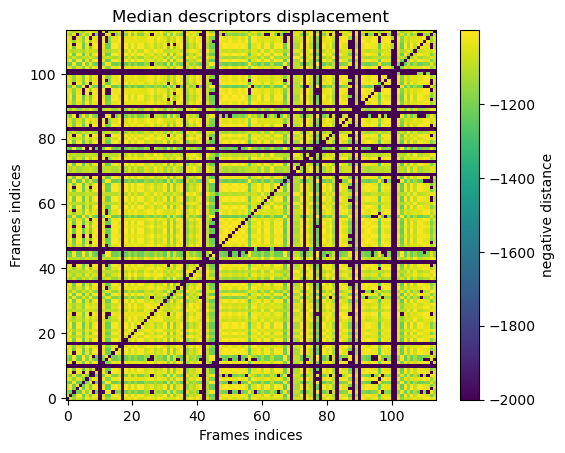

In [44]:
import matplotlib.pyplot as plt
# Create the heatmap
plt.imshow(-displacement_matrix, cmap='viridis', origin='lower') # 'viridis' is a common colormap, 'origin' sets the (0,0) position
plt.colorbar(label='negative distance') # Add a colorbar for interpretation
plt.title('Median descriptors displacement')
plt.xlabel('Frames indices')
plt.ylabel('Frames indices')
plt.show()

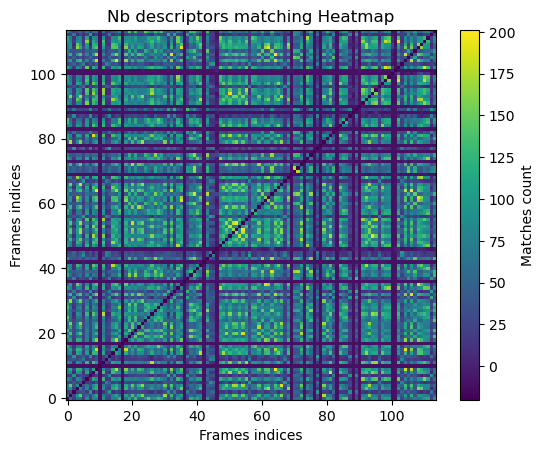

In [45]:
import matplotlib.pyplot as plt
# Create the heatmap
plt.imshow(matches_count_matrix, cmap='viridis', origin='lower') # 'viridis' is a common colormap, 'origin' sets the (0,0) position
plt.colorbar(label='Matches count') # Add a colorbar for interpretation
plt.title('Nb descriptors matching Heatmap')
plt.xlabel('Frames indices')
plt.ylabel('Frames indices')
plt.show()


# Sorting

This function reconstructs the approximate frame order of a shuffled video by iteratively selecting the next most likely neighboring frame.

The selection is based on two criteria: 

(1) the number of matching SIFT descriptors between frames, and

(2) the median displacement of matched keypoints.

These two matrices are used to choose the next frame and to determine when the “tail” of the video has been reached,
at which point the direction of sequence construction reverses.

In [46]:
def sort_frames(matches_count_matrix, displacement_matrix):
    """Sorts video frames into their correct temporal order.

    The algorithm:
      1. Starts from an initial frame (`head`).
      2. Iteratively selects among the top candidates with the highest match
         counts, choosing the one with the smallest median displacement.
      3. Builds the sequence forward until reaching the tail.
      4. Reverses direction and prepends frames until no valid matches remain.

    Args:
        matches_count_matrix (np.ndarray):
            A square matrix where entry (i, j) is the number of matching SIFT
            descriptors between frame `i` and frame `j`.
        displacement_matrix (np.ndarray):
            A square matrix where entry (i, j) represents the median
            displacement of matched keypoints between frames `i` and `j`.

    Returns:
        list[int]:
            A list of frame indices representing the estimated correct ordering
            of the video after filtering and reconstruction.
    """
    # Copy the matches count matrix to be able to edit it when sorting
    matches_count_matrix_copy = deepcopy(matches_count_matrix)
    
    # Select by default one frame to be temporary the head of our video
    head = 11

    # Instantiate the sequence as a deque
    sequence = deque()
    sequence.append(head)
    id_ = head
    # variable to be set to True when video end reached
    # used to know the direction of building the sequence
    already_found_tail = False

    # minimum number of matching features to consider that
    # there is a match between two frames
    nb_match_threshold = 20

    while len(sequence)<= len(frames):
        # Find 5 best candidates based on number of matching descriptors
        k = 5
        sorted_indices = np.argsort(matches_count_matrix_copy[id_])[::-1]
        # Use these indices to get the lower median displacement among the 5 frames
        next_indice = displacement_matrix[id_][sorted_indices[:k]].argmin()
        next_id = sorted_indices[next_indice]
    
        # Defining a matching condition used to filter the fake frames
        condition_matching = matches_count_matrix_copy[id_,next_id] > nb_match_threshold
    
        # Defining a condition to switch the direction of building the frames sequence
        matches_with_head_more = (next_id == head) or (matches_count_matrix_copy[id_,head] > matches_count_matrix_copy[id_,next_id] + 10)

        if condition_matching:
            if not matches_with_head_more:
                matches_count_matrix_copy[next_id,id_] = -1
                matches_count_matrix_copy[:,next_id] = -1

                if not already_found_tail:
                    sequence.append(next_id)
                else:
                    sequence.appendleft(next_id)

                id_ = next_id

            elif not already_found_tail :
                already_found_tail = True
                matches_count_matrix_copy[:,head] = -1
                id_ = head
                print("Video tail found, Changing to the other direction.")
            else:
                print("Exception: Found tail two times.")
                break
        else:
            print("Stopping: Remaining frames don't match with the last one, they will be filtered")
            break

    print(f"After filtering and sorting, the video has now {len(sequence)} frames")
    return list(sequence)


In [47]:
# Executing the sorting algorithm
sorted_frames_indices = sort_frames(matches_count_matrix, displacement_matrix)
# Getting the new ordered frame
sorted_frames = list(map(frames.__getitem__, sorted_frames_indices))

Video tail found, Changing to the other direction.
Stopping: Remaining frames don't match with the last one, they will be filtered
After filtering and sorting, the video has now 99 frames


In [ ]:
import math
n = len(sorted_frames)
columns=5
rows = math.ceil(n / columns)
plt.figure(figsize=(3 * columns, 3 * rows))

for i, frame in enumerate(sorted_frames):
    plt.subplot(rows, columns, i + 1)
    plt.imshow(frame)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Or other codecs like 'MJPG'
fps = 30.0
# Get frame size (width, height) from the first frame
height, width, layers = sorted_frames[0].shape
frame_size = (width, height)

out = cv2.VideoWriter(output_file, fourcc, fps, frame_size)

for frame in sorted_frames[::-1]:
    out.write(frame)

# Release the VideoWriter object
out.release()
print(f"Video saved to {output_file}")

Video saved to output.mp4
